# Ligand-Receptor Analysis

`liana` provides different statistical methods to infer `ligand-receptor` interactions from single-cell transcriptomics data omics data using prior knowledge.
In this notebook we showcase how to use liana in its most basic form with toy data.

## Loading Packages

In [1]:
# import liana
import liana as li

# needed for visualization and toy data
import scanpy as sc

## Loading data

In the most general case, `liana`'s ligand-receptor methods use `anndata` objects with processed single-cell transcriptomics data, with pre-defined cell labels (identities), to infer ligand-receptor interactions among all pairs of cell identities.

In [2]:
adata = sc.datasets.pbmc68k_reduced()

The example single-cell data consists processed data with PBMCs cell types

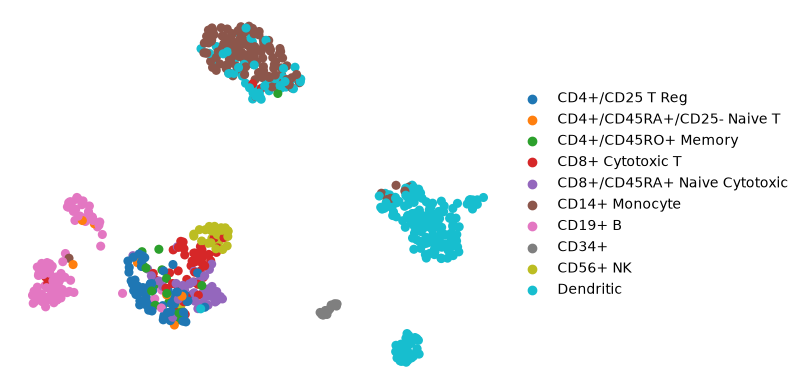

In [3]:
sc.pl.umap(adata, color="bulk_labels", title="", frameon=False)

## Background

`liana` typically works with the log1p-trasformed counts matrix, in this object the normalized counts are stored in `raw`:

In [4]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 174400 stored elements and shape (700, 765)>

Preferably, one would use `liana` with all features (genes) for which we have enough counts, but for the sake of this tutorial we are working with a matrix pre-filtered to the variable features alone.

In the background, `liana` aggregates the counts matrix and generates statistics, typically related to cell identies.
These statistics are then utilized by each of the methods in `liana`.

### Methods

In [5]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


Each method infers relevant ligand-receptor interactions relying on different assumptions and each method returns different ligand-receptor scores, typically a pair per method. One score corresponding to
the `magnitude` (strength) of interaction and the other reflecting how `specificity` of a given interaction to a pair cell identities.

For example, if the user wishes to learn more about liana's `rank_aggregate` implementation, where we combine the scores of multiple methods, they could do the following: 

In [6]:
# import liana's rank_aggregate
from liana.mt import rank_aggregate

In [7]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


## By default, LIANA+ uses **human gene symbols**. See the documentation and the [Prior Knowledge vignette](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html) for details and instructions for homology conversion.


## Example Run

### Individual Methods

In [8]:
# import all individual methods
from liana.method import (
    singlecellsignalr,
    connectome,
    cellphonedb,
    natmi,
    logfc,
    cellchat,
    geometric_mean,
)

<div class="alert alert-info">

**Note**

LIANA will by default use the `.raw` attribute of AnnData. If you wish to use .X set `use_raw` to `False`, or specify a `layer`.

LIANA will also by default use the 'consensus' resource to infer ligand-receptor interactions. 
This resource was created as a consensus from the resources literature-curated resources in OmniPath, and uses **human gene symbols**.

For different species, we provide 'mouseconsensus', for any other species you can provide your own resource, or translate LIANA's resources as shown [here](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html#Homology-Mapping).

If you wish to use a different resource, please specify it via the `resource_name` parameter for internal resources, or provide an external one via `resource` or `interactions`.
    
</div>  

In [9]:
# run cellphonedb
cellphonedb(
    adata,
    groupby="bulk_labels",
    # NOTE by default the resource uses HUMAN gene symbols
    resource_name="consensus",
    expr_prop=0.1,
    verbose=True,
    key_added="cpdb_res",
)

Using resource `consensus`.
Using `.raw`!
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


100%|███████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 790.40it/s]


By default, liana will be run **inplace** and results will be assigned to `adata.uns['liana_res']`.
Note that the high proportion of missing entities here is expected, as we are working on the reduced dimensions data.

In [10]:
# by default, liana's output is saved in place:
adata.uns["cpdb_res"].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
482,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.612842,0.421053,Dendritic,CD4+/CD45RO+ Memory,2.575263,0.0
321,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.596125,0.500000,Dendritic,CD4+/CD45RA+/CD25- Naive T,2.566905,0.0
989,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.483977,0.302326,Dendritic,CD14+ Monocyte,2.510830,0.0
651,HLA-DRA,HLA-DRA,4.537684,0.995833,LAG3,LAG3,0.399500,0.240741,Dendritic,CD8+ Cytotoxic T,2.468592,0.0
1392,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.373671,0.270833,Dendritic,Dendritic,2.455678,0.0


Here, we see that stats are provided for both ligand and receptor entities, more specifically: `ligand` and `receptor` are the two entities that potentially interact. As a reminder, CCC events are not limited to secreted signalling, but we refer to them as `ligand` and `receptor` for simplicity.

Also, in the case of heteromeric complexes, the `ligand` and `receptor` columns represent the subunit with minimum expression, while `*_complex` corresponds to the actual complex, with subunits being separated by `_`.

- `source` and `target` columns represent the source/sender and target/receiver cell identity for each interaction, respectively

- `*_props`: represents the proportion of cells that express the entity. 

  By default, any interactions in which either entity is not expressed in above 10% of cells per cell type is considered as a false positive,
  under the assumption that since CCC occurs between cell types, a sufficient proportion of cells within should express the genes.

- `*_means`: entity expression mean per cell type

- `lr_means`: mean ligand-receptor expression, as a measure of ligand-receptor interaction **magnitude**

- `cellphone_pvals`: permutation-based p-values, as a measure of interaction **specificity**

<div class="alert alert-info">

**Note**
    
`ligand`, `receptor`, `source`, and `target` columns are returned by every ligand-receptor method, while the rest of the columns can vary across the ligand-receptor methods, as each method infers relies on different assumptions and scoring functions, and hence each returns different ligand-receptor scores. Nevertheless, typically most methods use a pair of scoring functions - where one often corresponds to the **magnitude** (strength) of interaction and the other reflects how **specificity** of a given interaction to a pair cell identities.
    
</div>

#### Dotplot

We can now visualize the results that we just obtained.

LIANA provides some basic, but flexible plotting functionalities. Here, we will generate a dotplot of relevant ligand-receptor interactions.

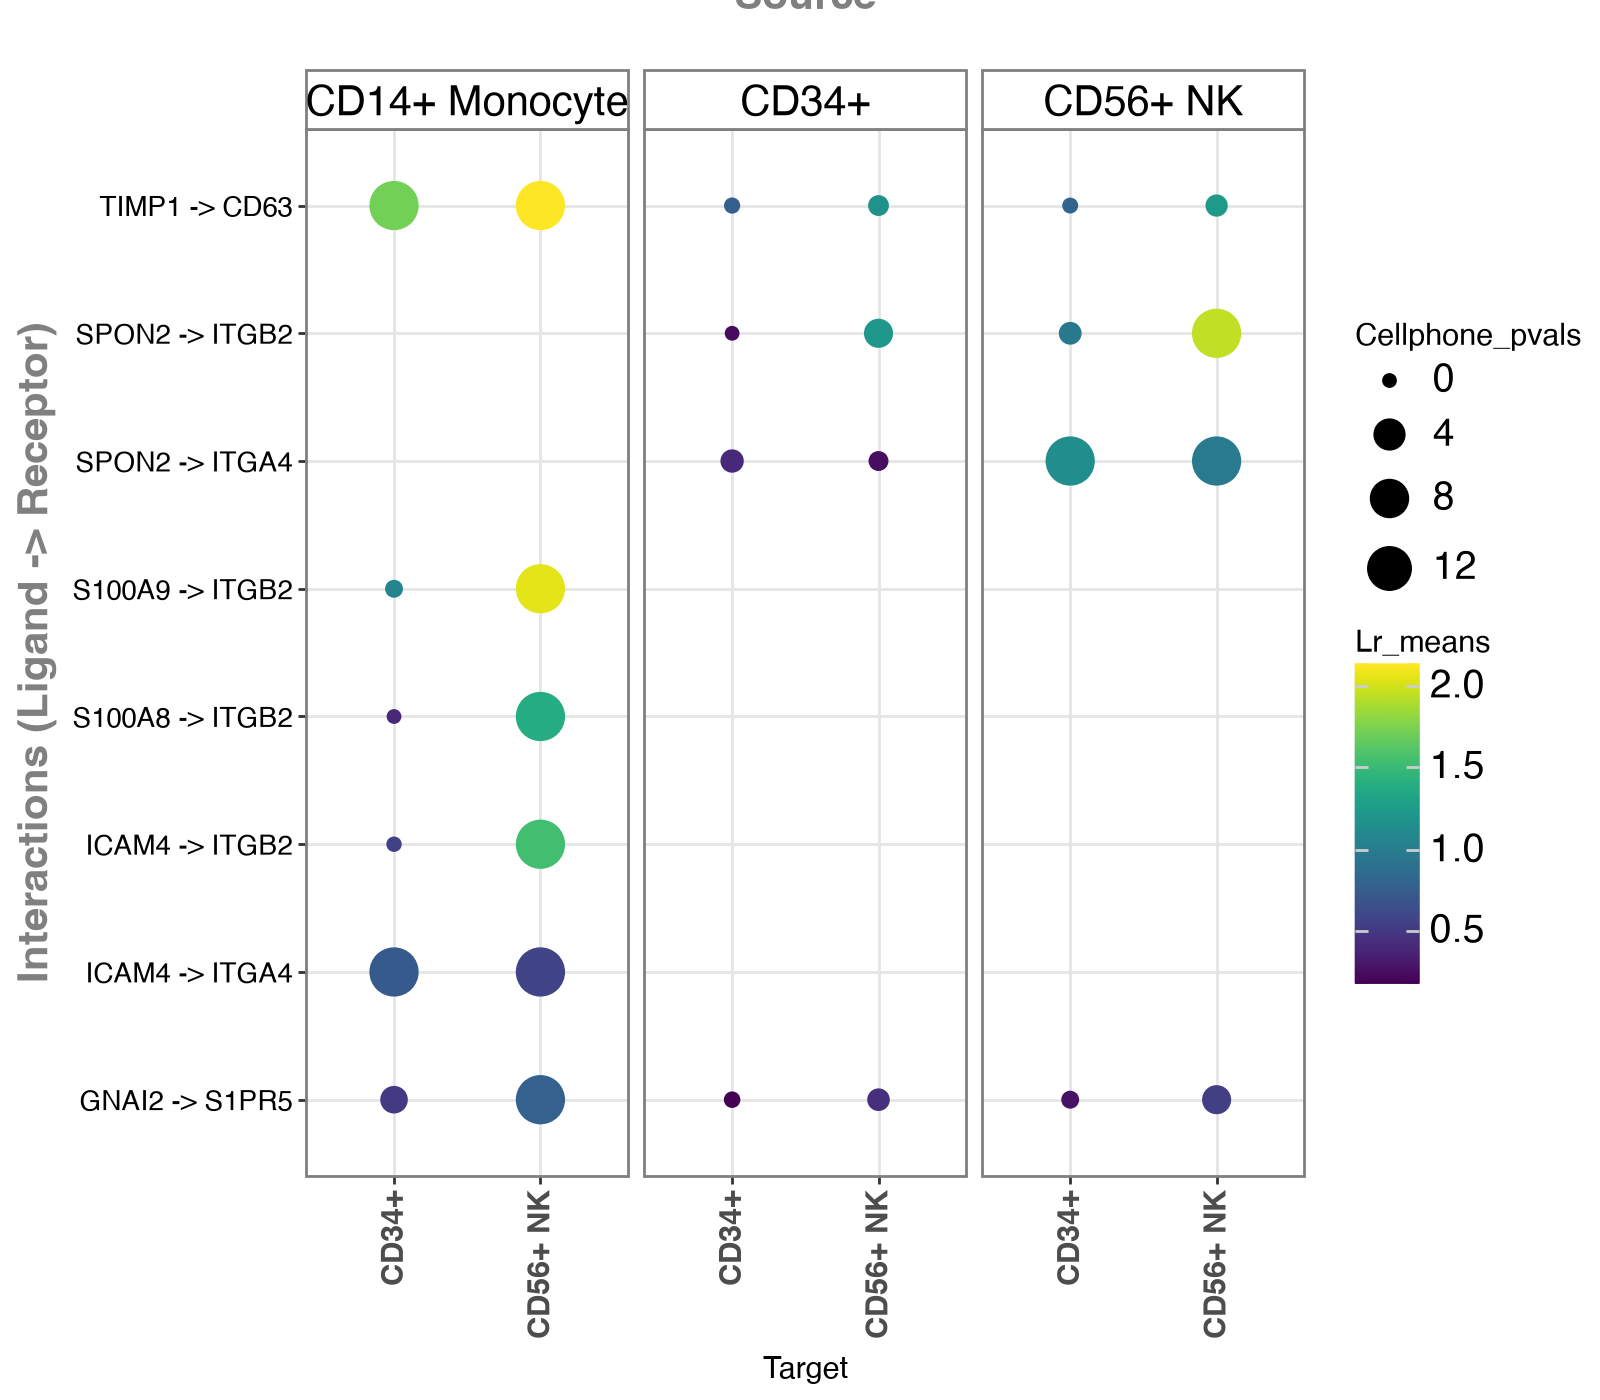

In [11]:
li.pl.dotplot(
    adata=adata,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
    source_labels=["CD34+", "CD56+ NK", "CD14+ Monocyte"],
    target_labels=["CD34+", "CD56+ NK"],
    figure_size=(8, 7),
    # finally, since cpdbv2 suggests using a filter to FPs
    # we filter the pvals column to <= 0.05
    filter_fun=lambda x: x["cellphone_pvals"] <= 0.05,
    uns_key="cpdb_res",  # uns_key to use, default is 'liana_res'
)

<div class="alert alert-info">
   
**Note**
    
Missing dots here would represent interactions for which the ligand and receptor are not expressed above the `expr_prop`. One can change this threshold by setting `expr_prop` to a different value. Alternatively, setting `return_all_lrs` to `True` will return all ligand-receptor interactions, regardless of expression.
</div>

#### Tileplot

While dotplots are useful to visualize the most relevant interactions, LIANA's tileplots are more useful when visualizing the statistics of ligands and receptors, individually.

/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/plotting/_common.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


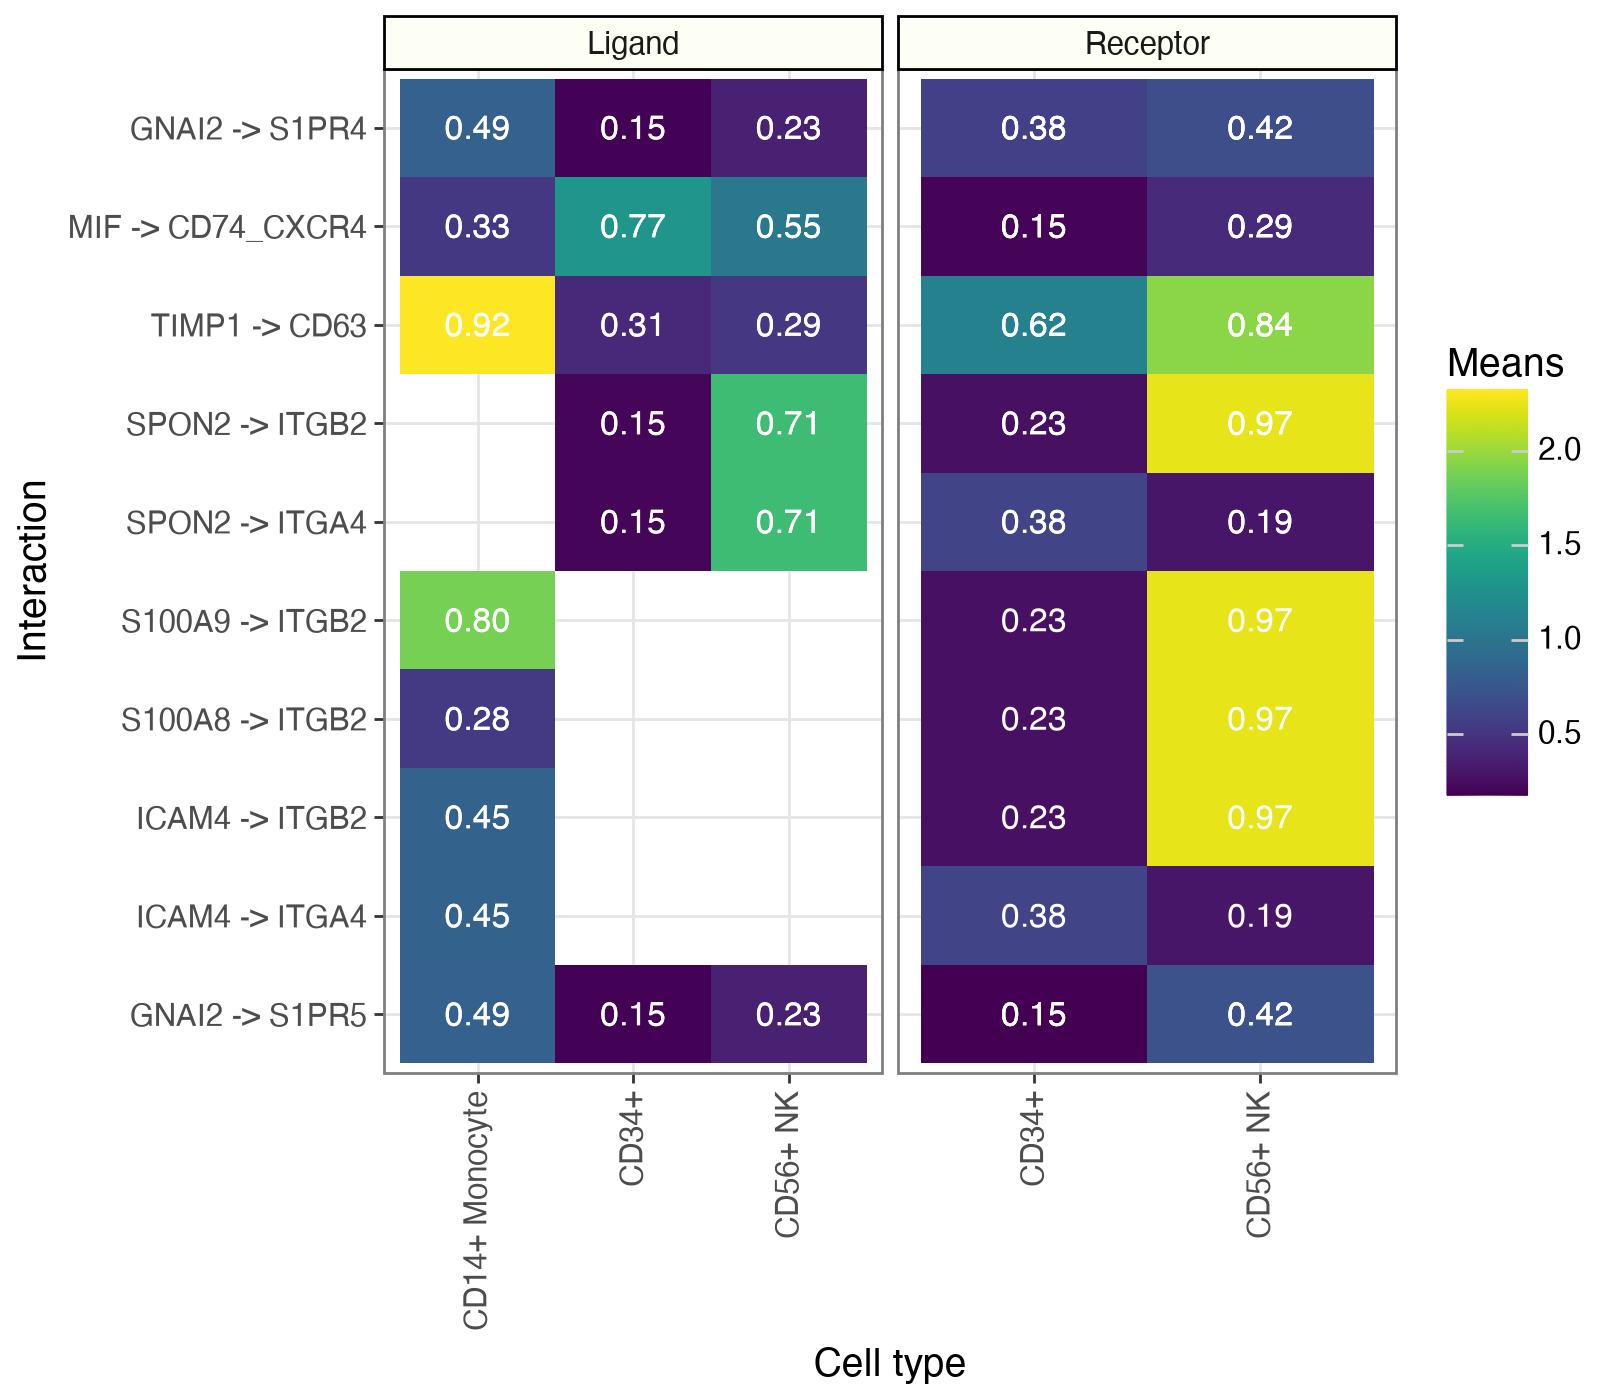

In [12]:
my_plot = li.pl.tileplot(
    adata=adata,
    # NOTE: fill & label need to exist for both
    # ligand_ and receptor_ columns
    fill="means",
    label="props",
    label_fun=lambda x: f"{x:.2f}",
    top_n=10,
    orderby="cellphone_pvals",
    orderby_ascending=True,
    source_labels=["CD34+", "CD56+ NK", "CD14+ Monocyte"],
    target_labels=["CD34+", "CD56+ NK"],
    uns_key="cpdb_res",  # NOTE: default is 'liana_res'
    source_title="Ligand",
    target_title="Receptor",
    figure_size=(8, 7),
)
my_plot

### Rank Aggregate
In addition to the individual methods, LIANA also provides a consensus that integrates the predictions of individual methods.
This is done by ranking and aggregating ([RRA](https://academic.oup.com/bioinformatics/article-abstract/28/4/573/213339)) the ligand-receptor interaction predictions from all methods.

In [13]:
# Run rank_aggregate
li.mt.rank_aggregate(
    adata, groupby="bulk_labels", resource_name="consensus", expr_prop=0.1, verbose=True
)

Using resource `consensus`.
Using `.raw`!
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(ad

Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|███████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 806.26it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [14]:
adata.uns["liana_res"].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1209,Dendritic,CD4+/CD45RO+ Memory,HLA-DRA,CD4,2.575263,0.0,2.780884,0.723815,1.431303,0.065077,0.736772,0.001137,0.000653
1188,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRA,CD4,2.566905,0.0,2.705027,0.709428,1.332656,0.063302,0.734081,0.001137,0.000911
1210,Dendritic,CD4+/CD45RO+ Memory,HLA-DRB1,CD4,2.415010,0.0,2.584465,0.712731,1.331341,0.060203,0.729607,0.001137,0.001211
1205,Dendritic,CD4+/CD45RO+ Memory,HLA-DPB1,CD4,2.367473,0.0,2.526199,0.731297,1.447014,0.068953,0.727352,0.001137,0.001377
1189,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRB1,CD4,2.406652,0.0,2.513965,0.698344,1.232695,0.058561,0.726870,0.001137,0.001741


In [15]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


The remainder of the columns in this dataframe are those coming from each of the methods included in the `rank_aggregate` - i.e. see the `show_methods` to map methods to scores.

#### Dotplot

We will now plot the most 'relevant' interactions ordered to the `magnitude_rank` results from aggregated_rank.

/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/plotting/_common.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


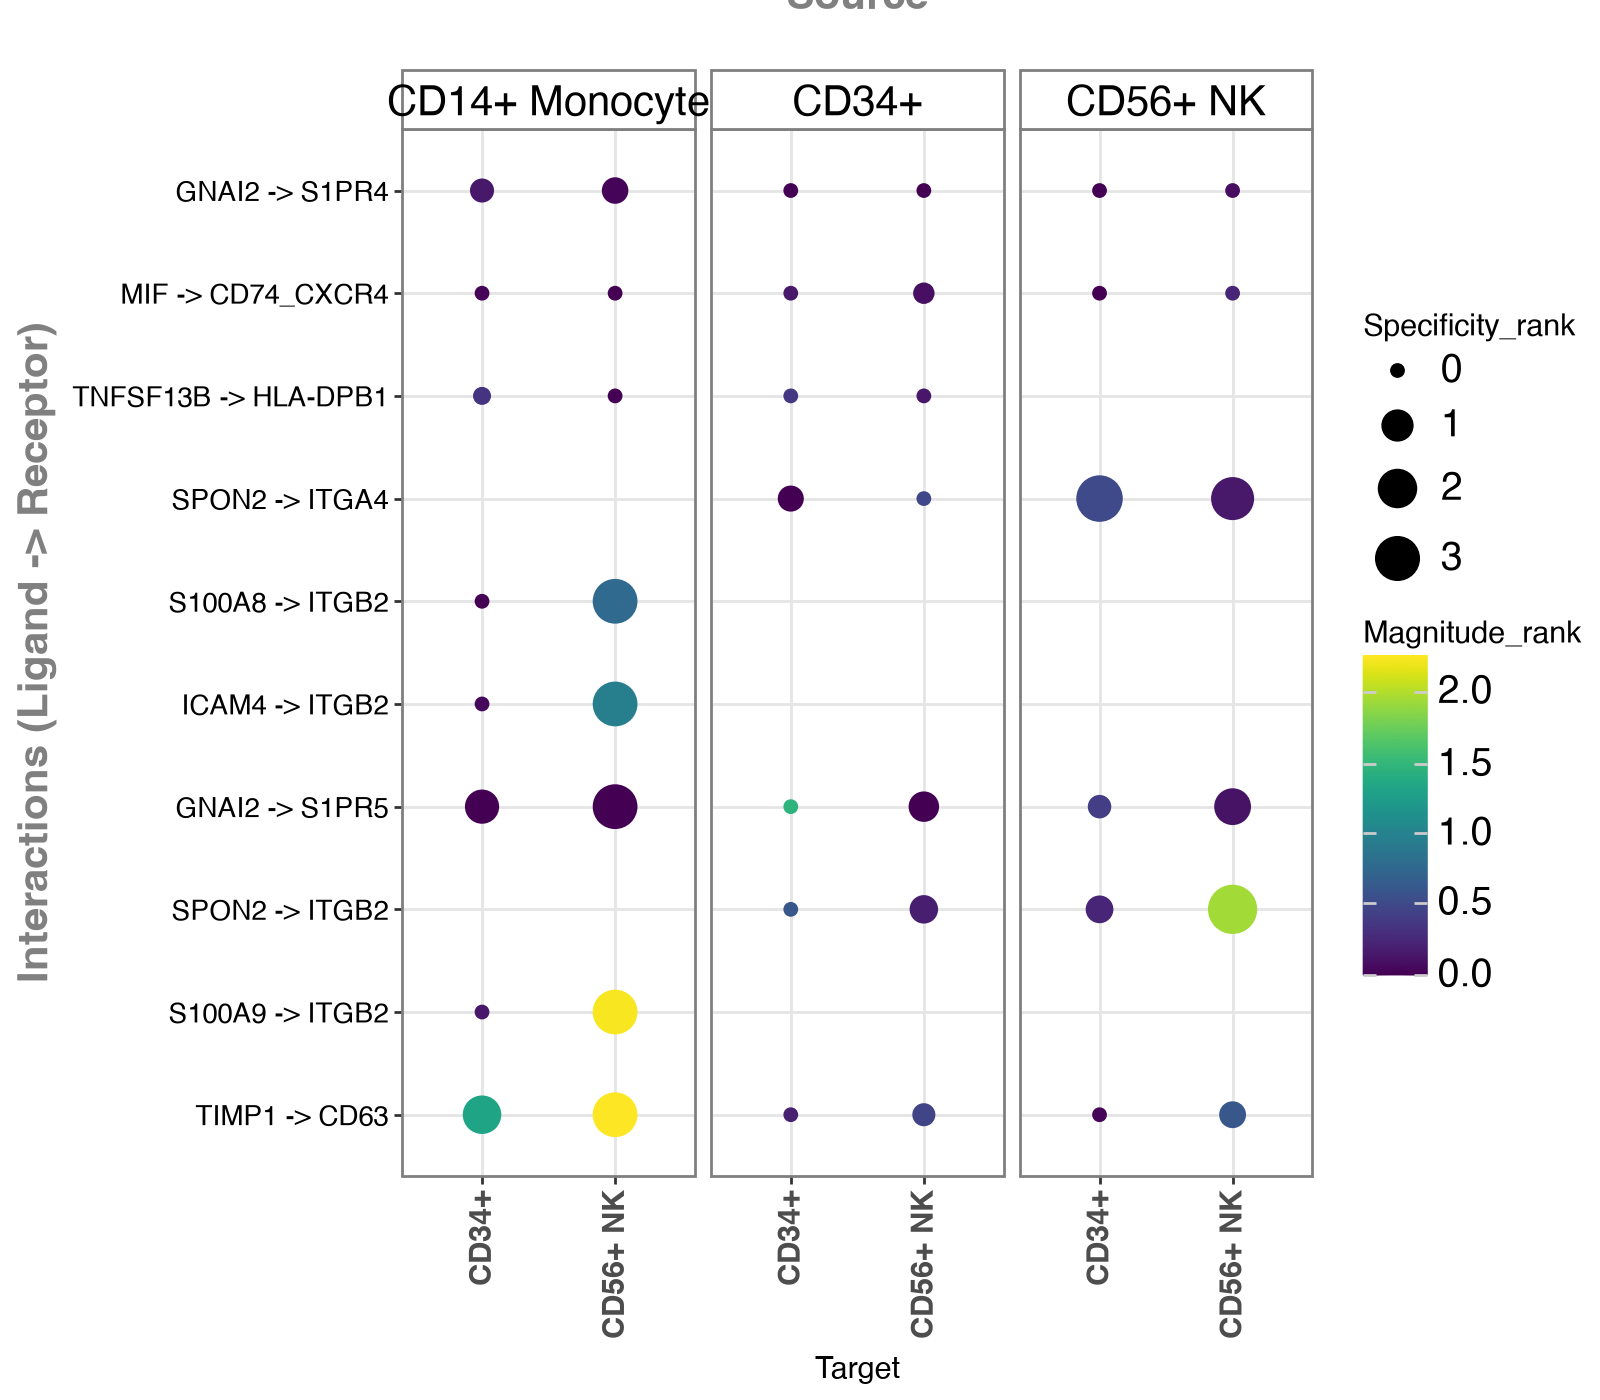

In [16]:
li.pl.dotplot(
    adata=adata,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_size=True,
    inverse_colour=True,
    source_labels=["CD34+", "CD56+ NK", "CD14+ Monocyte"],
    target_labels=["CD34+", "CD56+ NK"],
    top_n=10,
    orderby="magnitude_rank",
    orderby_ascending=True,
    figure_size=(8, 7),
)

Similarly, we can also treat the ranks provided by RRA as a probability distribution to which we can `filter` interactions
according to how robustly and highly ranked they are across the different methods.

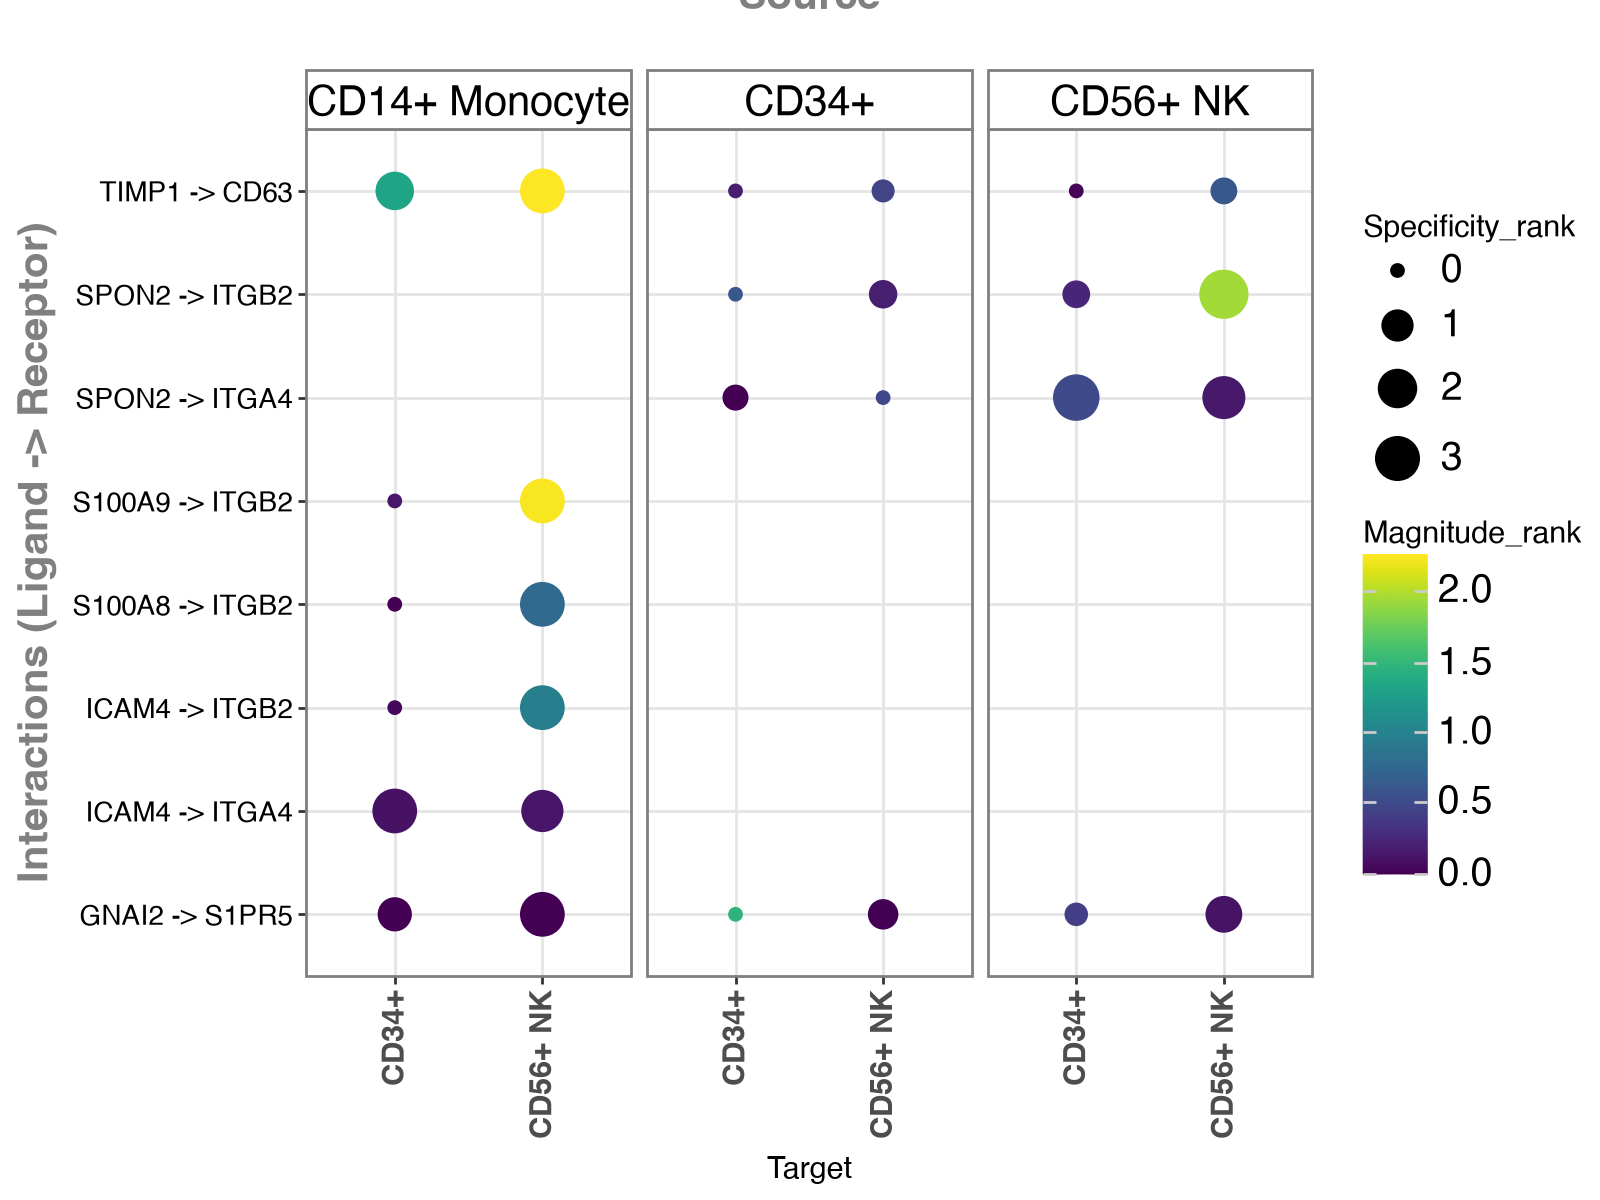

In [17]:
my_plot = li.pl.dotplot(
    adata=adata,
    colour="magnitude_rank",
    inverse_colour=True,
    size="specificity_rank",
    inverse_size=True,
    source_labels=["CD34+", "CD56+ NK", "CD14+ Monocyte"],
    target_labels=["CD34+", "CD56+ NK"],
    filter_fun=lambda x: x["specificity_rank"] <= 0.01,
)
my_plot

#### Circle Plot

While the majority of liana's plots are in plotnine, thanks to @WeipengMo, we also provide a circle plot (drawn in networkx):

<Axes: >

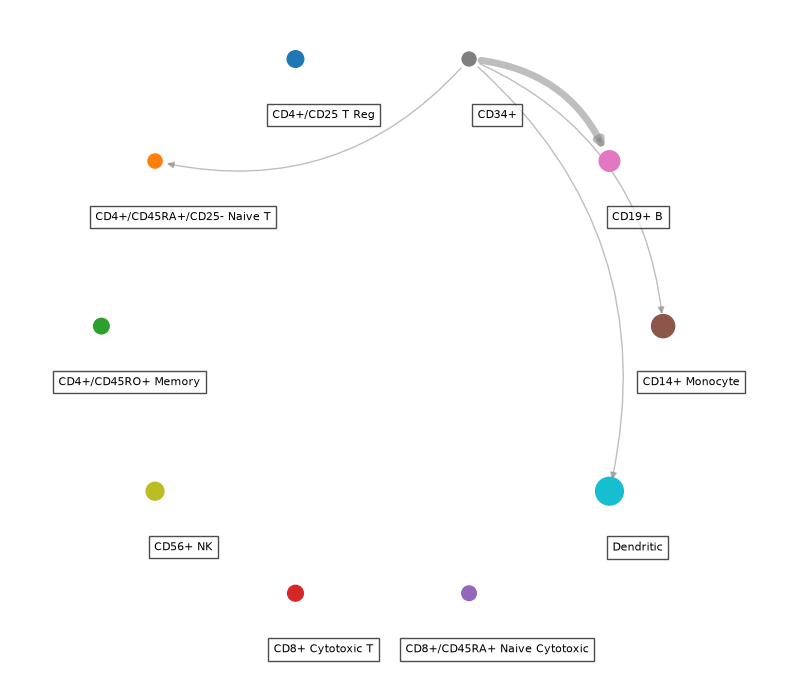

In [18]:
li.pl.circle_plot(
    adata,
    groupby="bulk_labels",
    score_key="magnitude_rank",
    inverse_score=True,
    source_labels="CD34+",
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    pivot_mode="counts",  # NOTE: this will simply count the interactions, 'mean' is also available
    figure_size=(10, 10),
)

## Customizing LIANA's rank aggregate

LIANA's rank aggregate is also customizable, and the user can choose to include only a subset of the methods.

For example, let's generate a consensus with geometric mean and logfc methods only:

In [19]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [20]:
new_rank_aggregate(
    adata,
    groupby="bulk_labels",
    expr_prop=0.1,
    verbose=True,
    # Note that with this option, we don't perform permutations
    # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
    n_perms=None,
    use_raw=True,
)

Using resource `consensus`.
Using `.raw`!
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/Users/tim.treis/Documents/GitHub/202609_workshop_GSCN/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future.

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running log2FC
Running Geometric Mean


Check the results

In [21]:
adata.uns["liana_res"].head()

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
110,CD14+ Monocyte,CD56+ NK,TIMP1,CD63,1.435272,2.126363,0.000776
109,CD14+ Monocyte,CD56+ NK,S100A9,ITGB2,1.069681,2.048953,0.001553
20,CD14+ Monocyte,CD14+ Monocyte,S100A9,ITGB2,1.069747,1.979753,0.002329
838,CD56+ NK,CD56+ NK,SPON2,ITGB2,1.860055,1.926317,0.003106
782,CD56+ NK,CD14+ Monocyte,SPON2,ITGB2,1.860121,1.861258,0.003882


## Task

Run different methods separately and then aggregate them. How different are the results? 

## Advance task

How can you combine GSEA with LRI? 

- Run GSEA limiting to the collection of KEGG pathways